# Loading Data and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cleans up string values like '€110.5M' or '€500K' and converts them into standard floats.
# If the value is missing or corrupted, it returns 0
def parse_player_value(val_str):
    if pd.isna(val_str):
        return 0.0
    
    # Strip the Euro symbol
    val_str = str(val_str).replace('€', '')
    
    # Handle Millions and Thousands
    if 'M' in val_str:
        return float(val_str.replace('M', '')) * 1_000_000
    elif 'K' in val_str:
        return float(val_str.replace('K', '')) * 1_000
    
    # Fallback for plain numbers
    try:
        return float(val_str)
    except ValueError:
        return 0.0

# Loads the FIFA 19 dataset and filters for the required numerical features.
def load_and_preprocess_data(filepath):

    df = pd.read_csv(filepath, encoding='cp1252')
    
    # The specific columns to analyze
    features = [
        'Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed', 
        'Strength', 'Stamina', 'Interceptions', 'StandingTackle', 'Value'
    ]
    
    df = df.dropna(subset=features + ['Position'])
    
    df['Value'] = df['Value'].apply(parse_player_value)
    
    # Extract the features as a NumPy array (X) and the positions as our labels (y)
    X = df[features].values
    y = df['Position'].values
    
    return X, y, df


X, y, df = load_and_preprocess_data('kl.csv')

# Run PCA algorithm

In [4]:
def run_numpy_pca(X):

    # Calculate the mean and standard deviation for each feature across the whole dataset
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Prevent division by zero just in case a feature has no variance
    sigma[sigma == 0] = 1e-8 
    
    X_std = (X - mu) / sigma
    
    # Covariance Matrix
    cov_matrix = np.cov(X_std, rowvar=False)
    
    # Extract the eigenvalues and eigenvectors from the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort eigenvalues in descending order to find the components that explain the most variance
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Select the top 2 eigenvectors to squash our data down into 2D space
    projection_matrix = sorted_eigenvectors[:, :2]
    
    # Multiply the original standardized data by our projection matrix to get the final coordinates
    X_pca = np.dot(X_std, projection_matrix)
    
    return X_pca, sorted_eigenvalues, projection_matrix

# Run the PCA algorithm
X_pca, eig_vals, proj_mat = run_numpy_pca(X)

# Visualization

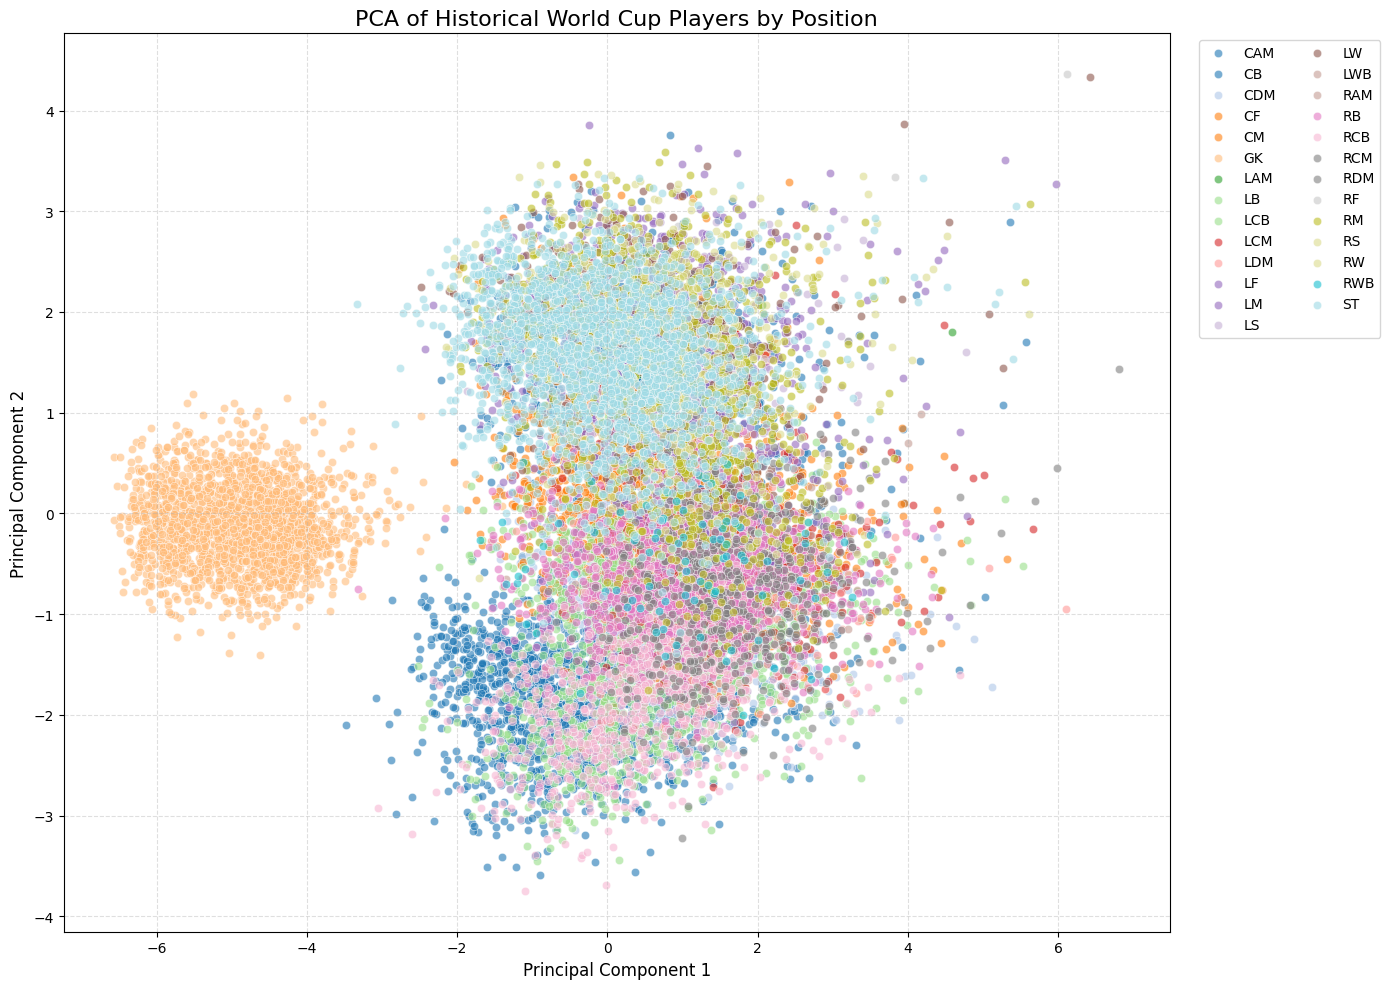

In [6]:
def visualize_pca(X_pca, y):

    plt.figure(figsize=(14, 10))
    
    # Grab all the unique positions to loop through them
    unique_positions = np.unique(y)
    
    cmap = plt.get_cmap('tab20')
    
    # Plot each position group one by one
    for i, position in enumerate(unique_positions):
        idx = (y == position)
        
        plt.scatter(
            X_pca[idx, 0], 
            X_pca[idx, 1], 
            label=position, 
            color=cmap(i / len(unique_positions)),
            alpha=0.6,
            edgecolors='white',
            linewidth=0.5
        )
        
    plt.title('PCA of Historical World Cup Players by Position', fontsize=16)
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    

    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


visualize_pca(X_pca, y)